SCENARIO 1

Predict ocean water temperature using environmental and depth-related features.
Dataset (Kaggle – Public):
https://www.kaggle.com/datasets/sohier/calcofi
Target Variable:
•	Water Temperature (T_degC)
Sample Input Features
•	Depth (m)
•	Salinity
•	Oxygen
•	Latitude
•	Longitude

IN-LAB TASKS
•	Import necessary Python libraries (NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn).
•	Load the CalCOFI dataset into a Pandas DataFrame
•	Select relevant numerical features and target variable.
•	Handle missing values using mean/median imputation.
•	Perform feature scaling using StandardScaler.
•	Split the dataset into training and testing sets.
•	Train a Linear Regression model using Scikit-learn.
•	Predict water temperature for test data.
•	Evaluate model performance using:
– Mean Squared Error (MSE)
– Root Mean Squared Error (RMSE)
– R² Score
•	Visualize:
– Actual vs Predicted temperature
– Residual errors
•	Optimize model performance using:
– Feature selection
– Regularization (Ridge / Lasso)


NEHA.N.K | 24BAD078

Handling missing values using mean imputation...

Training Linear Regression model...
Model training completed
Predictions generated

Model Performance:
Mean Squared Error (MSE): 6.2214468826180624
Root Mean Squared Error (RMSE): 2.4942828393384064
R² Score: 0.6492792001567064


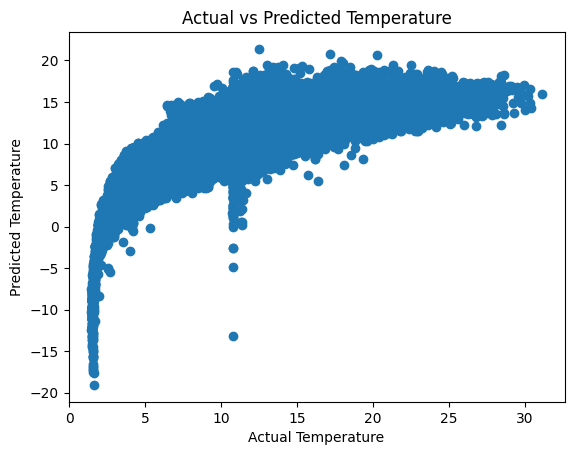

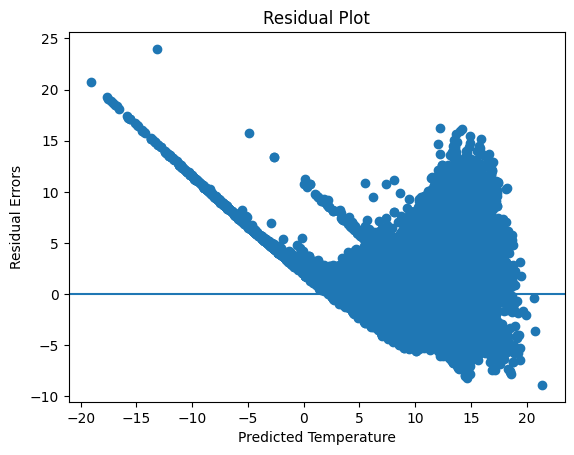


Applying Ridge Regression...
Ridge R² Score: 0.649279200458081

Applying Lasso Regression...
Lasso R² Score: 0.6492263454624063


In [1]:
# NEHA.N.K | 24BAD078
# Linear regression

# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score

print("NEHA.N.K | 24BAD078")
# loading dataset
ds=pd.read_csv("bottle.csv",encoding="ISO-8859-1"
               ,low_memory=False)

# I/P and o/p
features = ["Depthm", "Salnty", "O2ml_L"]
target = "T_degC"

# selecting only required columns needed for analysis
data = ds[features+[target]]

# Fill missing values in data using mean
print("\nHandling missing values using mean imputation...")
data=data.fillna(data.mean())

# Assigning variables
X = data[features]
y = data[target]

#feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#dividing dataset into test data & train data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("\nTraining Linear Regression model...")
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Model training completed")

# prediction
y_pred = lr.predict(X_test)
print("Predictions generated")

# model evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\nModel Performance:")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

# Visualisation
#scatter plot- because it shows relationship bw to variables
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()

residuals = y_test - y_pred #error
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Temperature")
plt.ylabel("Residual Errors")
plt.title("Residual Plot")
plt.show()

#Regularisation
print("\nApplying Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
print("Ridge R² Score:", r2_score(y_test, ridge_pred))

print("\nApplying Lasso Regression...")
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
print("Lasso R² Score:", r2_score(y_test, lasso_pred))

SCENARIO 2:
Classify whether LIC stock price will increase (1) or decrease (0) based on historical data.
Dataset (Kaggle – Public):
https://www.kaggle.com/datasets/debashis74017/lic-stock-price-data
Target Variable (Derived):
• Price Movement
– 1 → Closing price > Opening price
– 0 → Closing price ≤ Opening price
Input Features:
• Open
• High
• Low
• Volume

IN-LAB TASKS (Logistic Regression)
•	Import required Python libraries.
•	Load LIC stock dataset into Pandas.
•	Create a binary target variable (Price Movement).
•	Handle missing values.
•	Perform feature scaling.
•	Split the dataset into training and testing sets.
•	Train a Logistic Regression model.
•	Predict stock movement for test data.
•	Evaluate classification performance using:
– Accuracy
– Precision
– Recall
– F1-Score
– Confusion Matrix
•	Visualize:
– ROC Curve
– Feature importance
•	Optimize model using:
– Hyperparameter tuning (C, penalty)
– Regularization


NEHA.N.K | 24BAD078

Handling missing values using mean imputation...

Training Linear Regression model...
Model training completed
Predictions generated

Model Performance:
Accuracy: 0.6255088195386703
Precision: 1.0
Recall: 0.061224489795918366
F1 Score: 0.11538461538461539

Confusion Matrix:
 [[443   0]
 [276  18]]


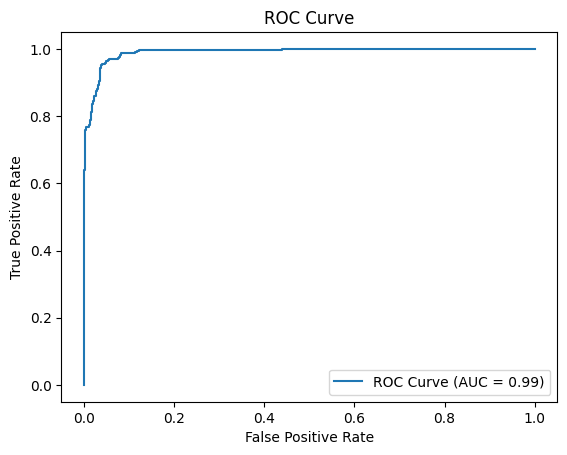

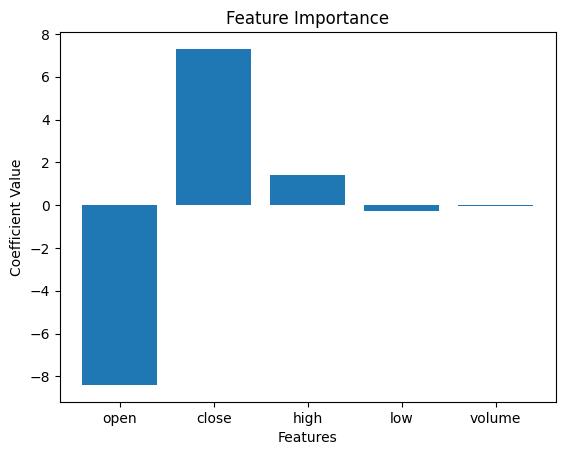


Applying regularization with tuned parameters...
Tuned Model Accuracy: 0.6078697421981004


In [3]:
# NEHA.N.K | 24BAD078
# Logistic regression

# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, roc_curve, auc

print("NEHA.N.K | 24BAD078")
# loading dataset
ds=pd.read_csv("/LICI - 10 minute data.csv",encoding="ISO-8859-1")

# create target variable
ds["price_Movement"]= np.where(ds["close"] > ds["open"], 1, 0)

# I/P and o/p
features = ["open","close","high", "low", "volume"]
X = ds[features]
y = ds["price_Movement"]

# Fill missing values in data using mean
print("\nHandling missing values using mean imputation...")
X=X.fillna(X.mean())

#feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#dividing dataset into test data & train data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("\nTraining Linear Regression model...")
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
print("Model training completed")

# prediction
y_pred = log_reg.predict(X_test)
print("Predictions generated")

# model evaluation
print("\nModel Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ROC curve
y_prob = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %.2f)" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# feature importance
importance = log_reg.coef_[0]

plt.figure()
plt.bar(features, importance)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Feature Importance")
plt.show()

# hyperparameter tuning
print("\nApplying regularization with tuned parameters...")
log_reg_tuned = LogisticRegression(C=0.5, penalty="l2", max_iter=1000)
log_reg_tuned.fit(X_train, y_train)

tuned_pred = log_reg_tuned.predict(X_test)
print("Tuned Model Accuracy:", accuracy_score(y_test, tuned_pred))
